# Análisis de Marketing — Alojamientos Turísticos
Precio medio por tipo de alojamiento y ciudad

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

df = pd.read_csv('cleaned_tourist_accommodation_20_04.csv')

# ── Paleta de colores ─────────────────────────────────────────────────────────
AZUL_OSCURO    = '#1A4E6E'
AZUL_PRINCIPAL = '#2C7BB6'
TURQUESA       = '#74C2C9'
AZUL_CLARO     = '#B8DDE4'
FONDO_SUAVE    = '#E8F4F7'
GRIS_TEXTO     = '#4A4A4A'
GRIS_BORDE     = '#CCCCCC'
GRIS_GRID      = '#E0E0E0'

COLORES_TIPOS = [AZUL_OSCURO, AZUL_PRINCIPAL, TURQUESA, AZUL_CLARO]

# ── Variables compartidas ─────────────────────────────────────────────────────
TIPOS = ['Entire home/apt', 'Hotel room', 'Private room', 'Shared room']

pivot_precio = (
    df.groupby(['city', 'room_type'])['price_imputed']
    .mean()
    .unstack('room_type')
    .reindex(columns=TIPOS)
)
city_order   = pivot_precio['Entire home/apt'].sort_values(ascending=False).index
pivot_precio = pivot_precio.loc[city_order]
CITY_LABELS  = [c.capitalize() for c in pivot_precio.index]

## Fig 1 — Metric cards: precio medio por tipo

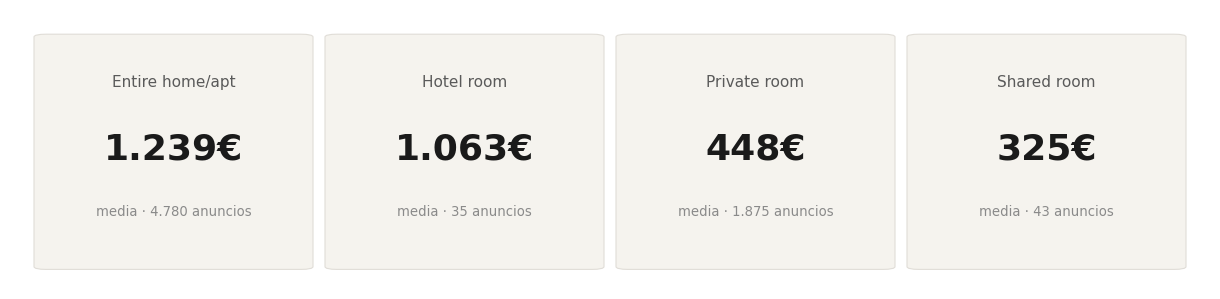

In [2]:
cards = []
for tipo in TIPOS:
    sub = df[df['room_type'] == tipo]
    cards.append({
        'label': tipo,
        'media': f"{sub['price_imputed'].mean():,.0f}€".replace(',', '.'),
        'sub':   f"media · {len(sub):,} anuncios".replace(',', '.')
    })

fig, ax = plt.subplots(figsize=(12, 2.8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
ax.axis('off')

n   = len(cards)
gap = 0.03
w   = (1 - (n + 1) * gap) / n

for i, card in enumerate(cards):
    x = gap + i * (w + gap)
    fancy = mpatches.FancyBboxPatch(
        (x, 0.08), w, 0.82,
        boxstyle='round,pad=0.01',
        transform=fig.transFigure,
        facecolor='#F5F3EE', edgecolor='#E0DDD7',
        linewidth=0.8, clip_on=False, zorder=2
    )
    fig.add_artist(fancy)
    cx = x + w / 2
    fig.text(cx, 0.74, card['label'], ha='center', va='center',
             fontsize=11, color='#5A5A5A', transform=fig.transFigure, zorder=3)
    fig.text(cx, 0.50, card['media'], ha='center', va='center',
             fontsize=26, fontweight='bold', color='#1A1A1A', transform=fig.transFigure, zorder=3)
    fig.text(cx, 0.28, card['sub'], ha='center', va='center',
             fontsize=9.5, color='#8A8A8A', transform=fig.transFigure, zorder=3)

plt.tight_layout(pad=0)
plt.savefig('fig1_metric_cards.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## Fig 2 — Precio medio global por tipo de alojamiento

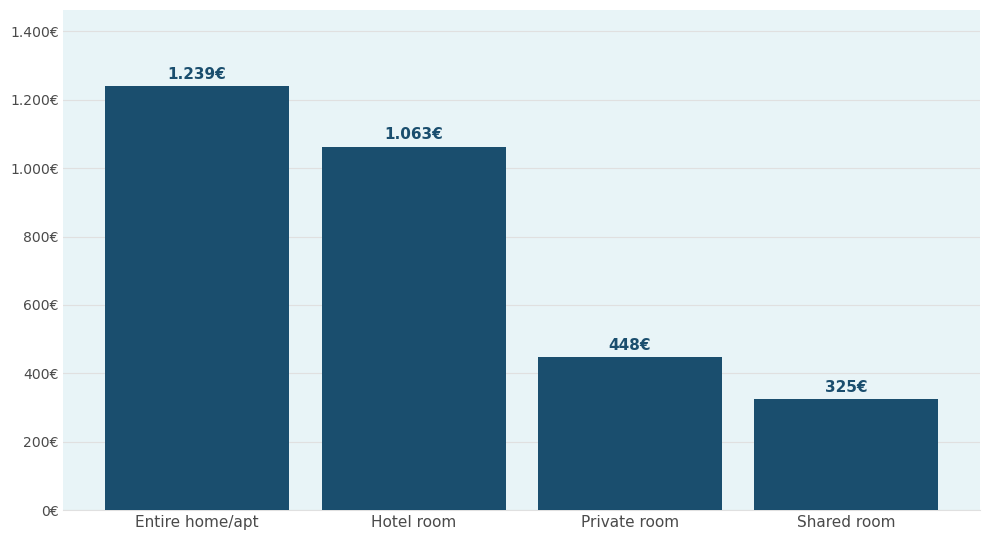

In [11]:
medias = [df[df['room_type'] == t]['price_imputed'].mean() for t in TIPOS]

fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor('white')
ax.set_facecolor(FONDO_SUAVE)

bars = ax.bar(TIPOS, medias, color=AZUL_OSCURO, width=0.85, zorder=3)

for bar, val in zip(bars, medias):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 12,
            f'{val:,.0f}€'.replace(',', '.'),
            ha='center', va='bottom', fontsize=11, fontweight='bold', color=AZUL_OSCURO)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}€'.replace(',', '.')))
ax.set_ylim(0, max(medias) * 1.18)
ax.yaxis.grid(True, linestyle='-', linewidth=0.8, color=GRIS_GRID, zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color(GRIS_GRID)
ax.tick_params(axis='x', labelsize=11, colors=GRIS_TEXTO, length=0)
ax.tick_params(axis='y', labelsize=10, colors=GRIS_TEXTO, length=0)

plt.tight_layout()
plt.savefig('fig2_precio_tipo.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## Fig 3 — Distribución de alojamientos por ciudad

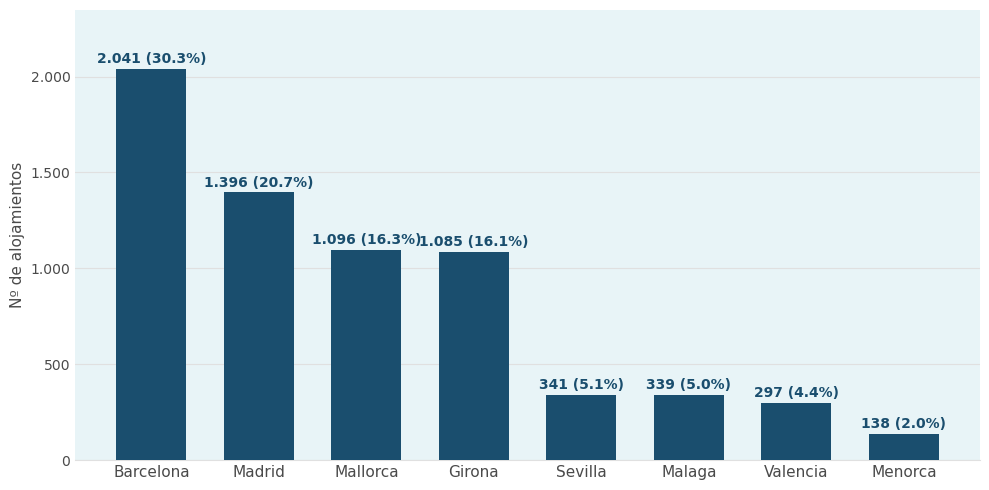

In [12]:
city_counts = (
    df.groupby('city')['apartment_id']
    .count()
    .sort_values(ascending=False)
    .reset_index()
)
city_counts.columns = ['city', 'count']
city_counts['city'] = city_counts['city'].str.capitalize()

# ── Porcentaje sobre el total ─────────────────────────────────────────────────
total = city_counts['count'].sum()
city_counts['pct'] = (city_counts['count'] / total * 100).round(1)

n       = len(city_counts)
palette = [AZUL_OSCURO]

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor(FONDO_SUAVE)

bars = ax.bar(city_counts['city'], city_counts['count'],
              color=palette[:n], width=0.65, zorder=3)

for bar, val, pct in zip(bars, city_counts['count'], city_counts['pct']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15,
            f"{val:,} ({pct}%)".replace(',', '.'),   # ← número + porcentaje
            ha='center', va='bottom', fontsize=10, fontweight='bold', color=AZUL_OSCURO)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'.replace(',', '.')))
ax.set_ylim(0, city_counts['count'].max() * 1.15)
ax.set_ylabel('Nº de alojamientos', fontsize=11, color=GRIS_TEXTO)
ax.yaxis.grid(True, linestyle='-', linewidth=0.8, color=GRIS_GRID, zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color(GRIS_GRID)
ax.tick_params(axis='x', labelsize=11, colors=GRIS_TEXTO, length=0)
ax.tick_params(axis='y', labelsize=10, colors=GRIS_TEXTO, length=0)

plt.tight_layout()
plt.savefig('fig3_alojamientos_ciudad.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## Fig 4 — Distribución de alojamientos por tipo

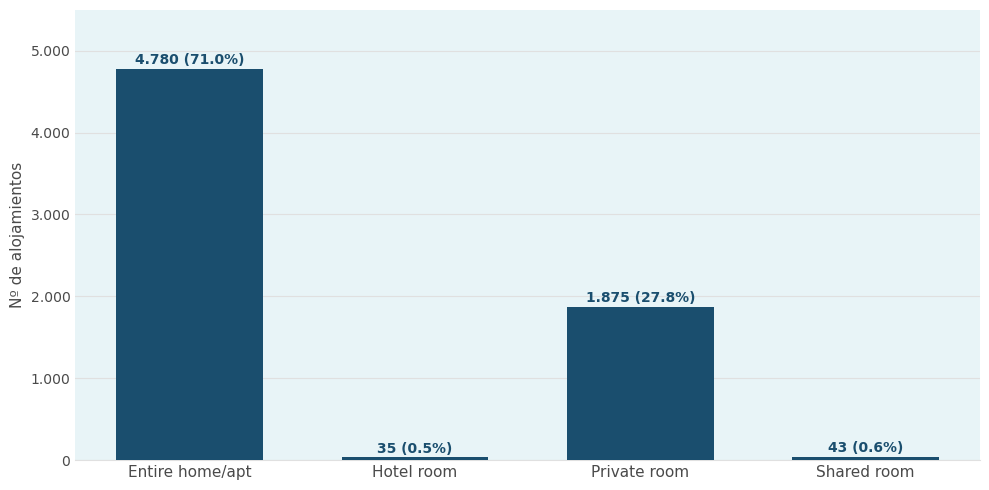

In [13]:
tipo_counts = (
    df.groupby('room_type')['apartment_id']
    .count()
    .reindex(TIPOS)
    .reset_index()
)
tipo_counts.columns = ['room_type', 'count']

# ── Porcentaje sobre el total ─────────────────────────────────────────────────
total = tipo_counts['count'].sum()
tipo_counts['pct'] = (tipo_counts['count'] / total * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor(FONDO_SUAVE)

bars = ax.bar(tipo_counts['room_type'], tipo_counts['count'],
              color=AZUL_OSCURO, width=0.65, zorder=3)

for bar, val, pct in zip(bars, tipo_counts['count'], tipo_counts['pct']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15,
            f"{val:,} ({pct}%)".replace(',', '.'),
            ha='center', va='bottom', fontsize=10, fontweight='bold', color=AZUL_OSCURO)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'.replace(',', '.')))
ax.set_ylim(0, tipo_counts['count'].max() * 1.15)
ax.set_ylabel('Nº de alojamientos', fontsize=11, color=GRIS_TEXTO)
ax.yaxis.grid(True, linestyle='-', linewidth=0.8, color=GRIS_GRID, zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color(GRIS_GRID)
ax.tick_params(axis='x', labelsize=11, colors=GRIS_TEXTO, length=0)
ax.tick_params(axis='y', labelsize=10, colors=GRIS_TEXTO, length=0)

plt.tight_layout()
plt.savefig('fig4_alojamientos_tipo.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## Fig 5 — Distribución por ciudad y tipo (barras agrupadas)

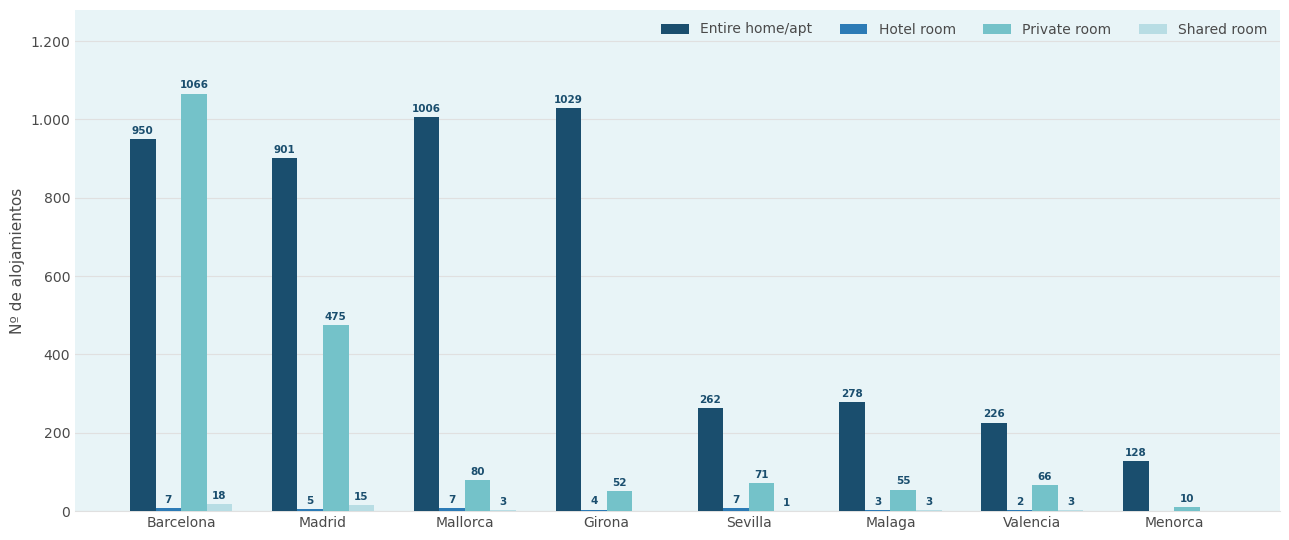

In [6]:
pivot_counts = (
    df.groupby(['city', 'room_type'])['apartment_id']
    .count()
    .unstack('room_type')
    .reindex(columns=TIPOS)
    .fillna(0)
)
pivot_counts = pivot_counts.loc[pivot_counts.sum(axis=1).sort_values(ascending=False).index]
city_labels  = [c.capitalize() for c in pivot_counts.index]

x       = np.arange(len(city_labels))
width   = 0.18
offsets = np.linspace(-(len(TIPOS) - 1) / 2, (len(TIPOS) - 1) / 2, len(TIPOS)) * width

fig, ax = plt.subplots(figsize=(13, 5.5))
fig.patch.set_facecolor('white')
ax.set_facecolor(FONDO_SUAVE)

for tipo, color, offset in zip(TIPOS, COLORES_TIPOS, offsets):
    vals = pivot_counts[tipo].values
    bars = ax.bar(x + offset, vals, width=width, color=color, label=tipo, zorder=3)
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 8,
                    f'{int(val)}', ha='center', va='bottom',
                    fontsize=7.5, fontweight='bold', color=AZUL_OSCURO)

ax.set_xticks(x)
ax.set_xticklabels(city_labels, fontsize=11, color=GRIS_TEXTO)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'.replace(',', '.')))
ax.set_ylim(0, pivot_counts.values.max() * 1.2)
ax.set_ylabel('Nº de alojamientos', fontsize=11, color=GRIS_TEXTO)
ax.legend(frameon=False, fontsize=10, labelcolor=GRIS_TEXTO, loc='upper right', ncol=4)
ax.yaxis.grid(True, linestyle='-', linewidth=0.8, color=GRIS_GRID, zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color(GRIS_GRID)
ax.tick_params(axis='both', length=0, labelsize=10, colors=GRIS_TEXTO)

plt.tight_layout()
plt.savefig('fig5_ciudad_tipo_counts.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## Fig 6 — Heatmap: precio medio por ciudad y tipo

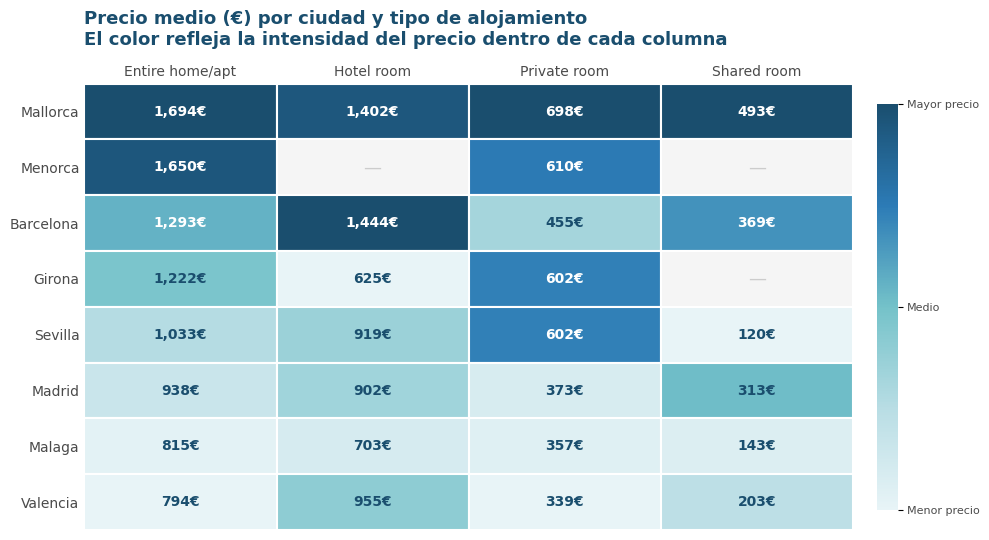

In [7]:
cmap = mcolors.LinearSegmentedColormap.from_list(
    'custom_blue', [FONDO_SUAVE, AZUL_CLARO, TURQUESA, AZUL_PRINCIPAL, AZUL_OSCURO]
)

n_cities = len(pivot_precio)
n_tipos  = len(TIPOS)

fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for j, tipo in enumerate(TIPOS):
    col_vals = pivot_precio[tipo].values.astype(float)
    col_min, col_max = np.nanmin(col_vals), np.nanmax(col_vals)

    for i, (val, city) in enumerate(zip(col_vals, CITY_LABELS)):
        x, y = j, n_cities - 1 - i
        if np.isnan(val):
            ax.add_patch(plt.Rectangle([x, y], 1, 1, facecolor='#F5F5F5', edgecolor='white', lw=1.5))
            ax.text(x + 0.5, y + 0.5, '—', ha='center', va='center', fontsize=13, color=GRIS_BORDE)
            continue
        norm_val = (val - col_min) / (col_max - col_min) if col_max > col_min else 0.5
        ax.add_patch(plt.Rectangle([x, y], 1, 1, facecolor=cmap(norm_val), edgecolor='white', lw=1.5))
        ax.text(x + 0.5, y + 0.5, f'{val:,.0f}€',
                ha='center', va='center', fontsize=10, fontweight='bold',
                color='white' if norm_val > 0.55 else AZUL_OSCURO)

ax.set_xlim(0, n_tipos)
ax.set_ylim(0, n_cities)
ax.set_xticks([j + 0.5 for j in range(n_tipos)])
ax.set_xticklabels(TIPOS, fontsize=10, color=GRIS_TEXTO)
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.set_yticks([n_cities - 1 - i + 0.5 for i in range(n_cities)])
ax.set_yticklabels(CITY_LABELS, fontsize=10, color=GRIS_TEXTO)
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title('Precio medio (€) por ciudad y tipo de alojamiento\n'
             'El color refleja la intensidad del precio dentro de cada columna',
             fontsize=13, fontweight='bold', color=AZUL_OSCURO, pad=28, loc='left')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.025, pad=0.03)
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels(['Menor precio', 'Medio', 'Mayor precio'], fontsize=8, color=GRIS_TEXTO)
cbar.outline.set_visible(False)

plt.tight_layout()
plt.savefig('fig6_heatmap_ciudad_tipo.png', dpi=150, bbox_inches='tight')
plt.show()

## Fig 7 — Entire home/apt vs Private room por ciudad

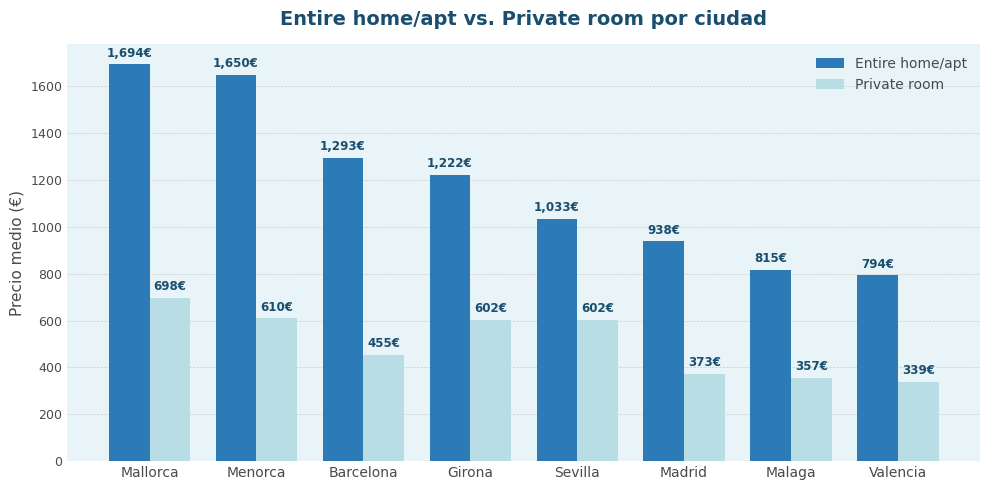

In [8]:
x       = np.arange(len(CITY_LABELS))
width   = 0.38
entire  = pivot_precio['Entire home/apt'].values
private = pivot_precio['Private room'].values

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor(FONDO_SUAVE)

b1 = ax.bar(x - width/2, entire,  width, label='Entire home/apt', color=AZUL_PRINCIPAL, zorder=3)
b2 = ax.bar(x + width/2, private, width, label='Private room',    color=AZUL_CLARO,    zorder=3)

for bar, val in zip(b1, entire):
    if not np.isnan(val):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                f'{val:,.0f}€', ha='center', va='bottom',
                fontsize=8.5, fontweight='bold', color=AZUL_OSCURO)

for bar, val in zip(b2, private):
    if not np.isnan(val):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                f'{val:,.0f}€', ha='center', va='bottom',
                fontsize=8.5, fontweight='bold', color=AZUL_OSCURO)

ax.set_xticks(x)
ax.set_xticklabels(CITY_LABELS, fontsize=10, color=GRIS_TEXTO)
ax.set_ylabel('Precio medio (€)', fontsize=11, color=GRIS_TEXTO)
ax.set_title('Entire home/apt vs. Private room por ciudad',
             fontsize=14, fontweight='bold', color=AZUL_OSCURO, pad=14)
ax.legend(frameon=False, fontsize=10, labelcolor=GRIS_TEXTO, loc='upper right')
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, color=GRIS_BORDE, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(axis='y', labelsize=9, colors=GRIS_TEXTO, length=0)
ax.tick_params(axis='x', length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig('fig7_barras_ciudad.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()